<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/Magnetic_Response_Curves_Per_Magnetic_Order.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

```
Magnetic order
│
├── Uncompensated net moment
│   ├── Ferromagnet
│   │   └── parallel moments
│   └── Ferrimagnet
│       └── antiparallel unequal moments
│
├── Compensated ordered moments
│   ├── Conventional antiferromagnet
│   │   └── compensated real space order
│   │       └── conventionally spin degenerate bands
│   │
│   └── Altermagnet
│       └── compensated real space order
│           └── crystal rotation connects opposite spins
│               └── alternating momentum spin splitting
│                   └── d, g, or higher even parity structure
│
└── Field induced moment
    └── Paramagnet
        └── susceptibility driven response
```

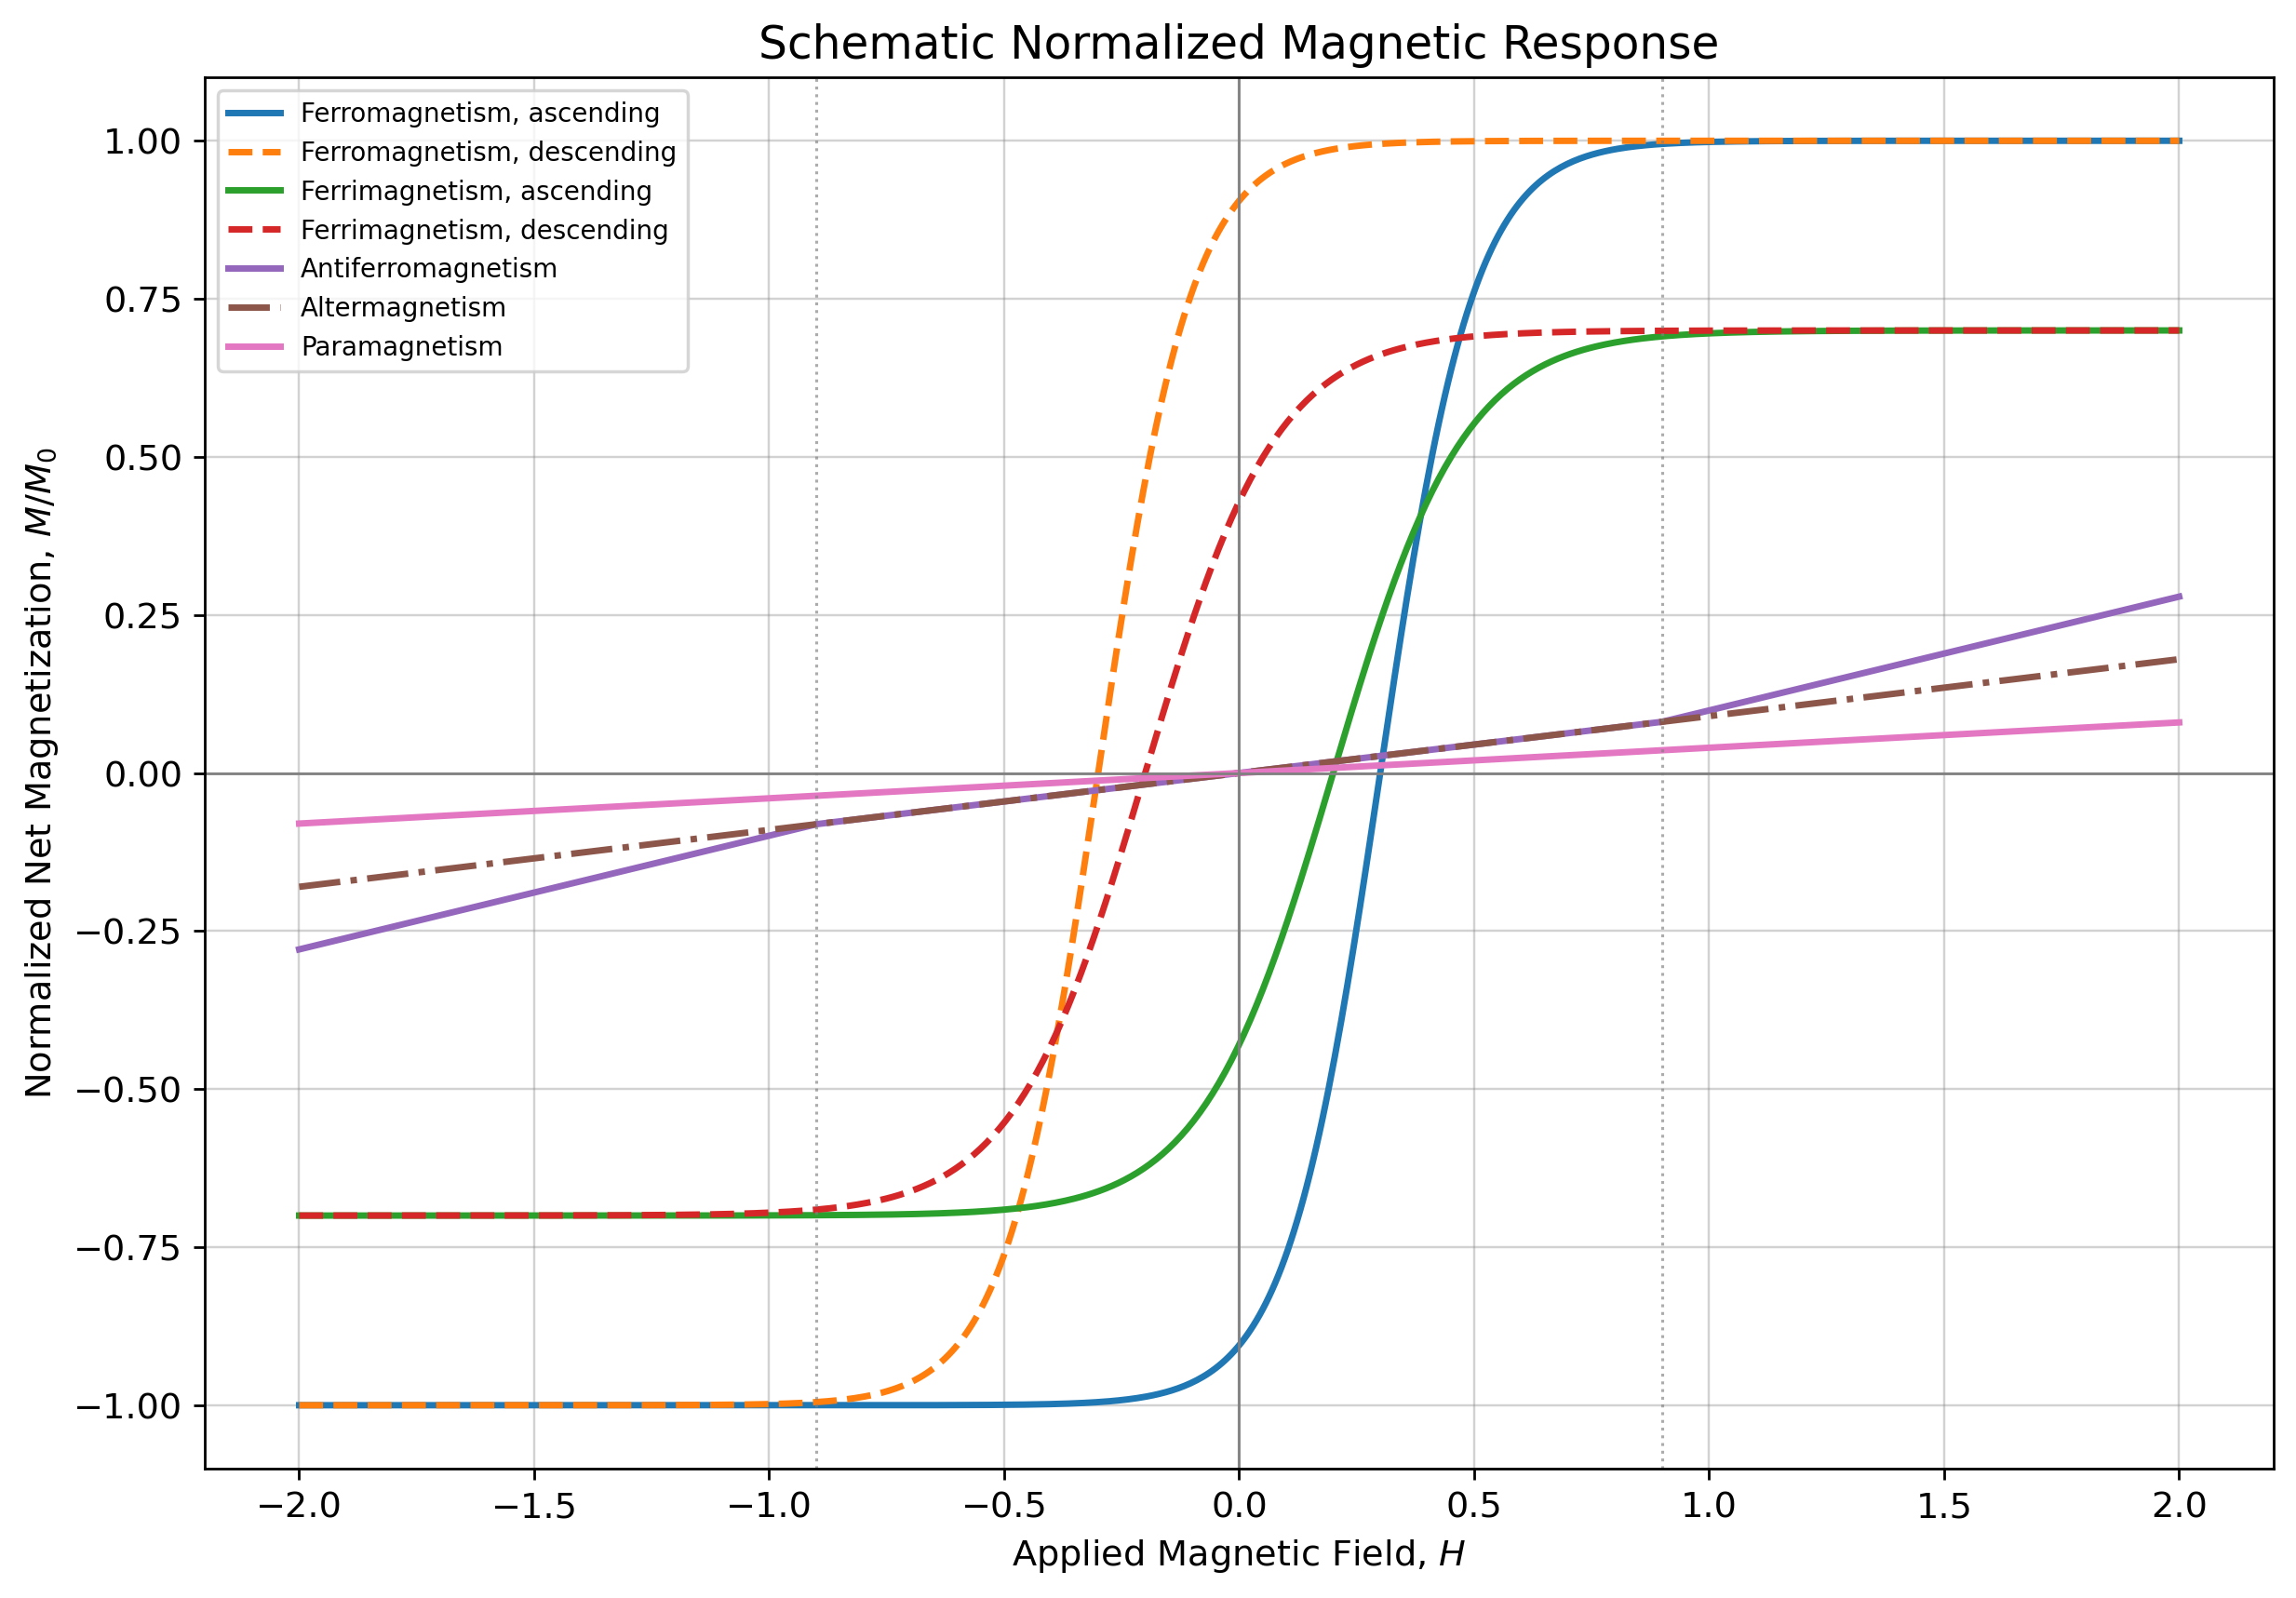

In [8]:
"""Plot schematic field responses for representative magnetic orders."""

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.axes import Axes
from numpy.typing import NDArray


# ------------------------------------------------------------
# TYPE ALIASES
# ------------------------------------------------------------

FloatArray = NDArray[np.float64]


# ------------------------------------------------------------
# CONTROL KNOBS
# ------------------------------------------------------------

FIELD_MIN = -2.0
FIELD_MAX = 2.0
FIELD_POINTS = 600

# Ferromagnetic hysteresis.
FERRO_SATURATION = 1.00
FERRO_COERCIVE_FIELD = 0.30
FERRO_SWITCHING_WIDTH = 0.20

# Ferrimagnetic hysteresis.
FERRI_SATURATION = 0.70
FERRI_COERCIVE_FIELD = 0.20
FERRI_SWITCHING_WIDTH = 0.28

# Compensated magnetic responses.
AFM_LOW_FIELD_SUSCEPTIBILITY = 0.09
AFM_SPIN_FLOP_FIELD = 0.90
AFM_POST_FLOP_SLOPE_MULTIPLIER = 2.00

# The altermagnetic net response initially matches the AFM susceptibility.
ALTERMAGNET_SUSCEPTIBILITY = AFM_LOW_FIELD_SUSCEPTIBILITY

# Weak field-induced paramagnetic response.
PARAMAGNET_SUSCEPTIBILITY = 0.04

# Spin-flop markers.
SHOW_SPIN_FLOP_MARKERS = True

# Figure configuration.
FIGURE_WIDTH_INCHES = 10.0
FIGURE_HEIGHT_INCHES = 7.0
FIGURE_DPI = 250
LINE_WIDTH = 2.0

GRID_COLOR = "gray"
GRID_ALPHA = 0.35
GRID_LINE_WIDTH = 0.7

REFERENCE_LINE_WIDTH = 0.8
SPIN_FLOP_LINE_WIDTH = 0.9
SPIN_FLOP_LINE_ALPHA = 0.65

TITLE_FONT_SIZE = 14
AXIS_LABEL_FONT_SIZE = 11
LEGEND_FONT_SIZE = 8


# ------------------------------------------------------------
# PLOTTING CONFIGURATION
# ------------------------------------------------------------


def configure_plotting() -> None:
    """Configure Matplotlib defaults for high-resolution Colab output."""
    plt.rcParams.update(
        {
            "figure.dpi": FIGURE_DPI,
            "savefig.dpi": FIGURE_DPI,
            "axes.grid": True,
            "grid.color": GRID_COLOR,
            "grid.alpha": GRID_ALPHA,
            "grid.linestyle": "-",
            "grid.linewidth": GRID_LINE_WIDTH,
            "font.size": 11,
        }
    )


# ------------------------------------------------------------
# HYSTERETIC MAGNETIZATION MODELS
# ------------------------------------------------------------


def calculate_hysteresis(
    field: FloatArray,
    saturation: float,
    coercive_field: float,
    switching_width: float,
) -> tuple[FloatArray, FloatArray]:
    """Calculate phenomenological ascending and descending hysteresis.

    The shifted hyperbolic-tangent branches represent saturation,
    remanence, coercivity, and a finite magnetic-reversal width.

    Args:
        field: Applied magnetic-field samples.
        saturation: Saturation magnetization in normalized units.
        coercive_field: Magnitude of the coercive field.
        switching_width: Width controlling magnetic reversal.

    Returns:
        Ascending and descending normalized magnetization branches.

    Raises:
        ValueError: If saturation is negative.
        ValueError: If coercive_field is negative.
        ValueError: If switching_width is zero or negative.
    """
    if saturation < 0.0:
        raise ValueError("saturation must be zero or positive.")

    if coercive_field < 0.0:
        raise ValueError("coercive_field must be zero or positive.")

    if switching_width <= 0.0:
        raise ValueError("switching_width must be greater than zero.")

    ascending = saturation * np.tanh(
        (field - coercive_field) / switching_width
    )

    descending = saturation * np.tanh(
        (field + coercive_field) / switching_width
    )

    return ascending, descending


# ------------------------------------------------------------
# LINEAR SUSCEPTIBILITY MODELS
# ------------------------------------------------------------


def calculate_linear_response(
    field: FloatArray,
    susceptibility: float,
) -> FloatArray:
    """Calculate a linear field-induced net magnetization.

    Args:
        field: Applied magnetic-field samples.
        susceptibility: Dimensionless schematic susceptibility.

    Returns:
        Field-induced normalized net magnetization.

    Raises:
        ValueError: If susceptibility is negative.
    """
    if susceptibility < 0.0:
        raise ValueError("susceptibility must be zero or positive.")

    return susceptibility * field


# ------------------------------------------------------------
# ANTIFERROMAGNETIC SPIN-FLOP MODEL
# ------------------------------------------------------------


def calculate_antiferromagnetic_response(
    field: FloatArray,
    low_field_susceptibility: float,
    spin_flop_field: float,
    post_flop_slope_multiplier: float,
) -> FloatArray:
    """Calculate a continuous schematic antiferromagnetic spin-flop response.

    Below the spin-flop field, the net magnetization follows the
    low-field susceptibility. Above the transition, the differential
    susceptibility increases by the specified multiplier.

    This model is phenomenological and represents an easy-axis
    antiferromagnet under a suitably oriented applied field.

    Args:
        field: Applied magnetic-field samples.
        low_field_susceptibility: Susceptibility below the spin flop.
        spin_flop_field: Magnitude of the spin-flop transition field.
        post_flop_slope_multiplier: Differential-susceptibility multiplier
            above the spin flop.

    Returns:
        Continuous odd-symmetric normalized net magnetization.

    Raises:
        ValueError: If low_field_susceptibility is negative.
        ValueError: If spin_flop_field is zero or negative.
        ValueError: If post_flop_slope_multiplier is below one.
    """
    if low_field_susceptibility < 0.0:
        raise ValueError(
            "low_field_susceptibility must be zero or positive."
        )

    if spin_flop_field <= 0.0:
        raise ValueError("spin_flop_field must be greater than zero.")

    if post_flop_slope_multiplier < 1.0:
        raise ValueError(
            "post_flop_slope_multiplier must be at least one."
        )

    absolute_field = np.abs(field)
    field_sign = np.sign(field)

    low_field_response = low_field_susceptibility * field

    magnetization_at_spin_flop = (
        low_field_susceptibility * spin_flop_field
    )

    post_flop_susceptibility = (
        low_field_susceptibility * post_flop_slope_multiplier
    )

    high_field_magnitude = (
        magnetization_at_spin_flop
        + post_flop_susceptibility
        * (absolute_field - spin_flop_field)
    )

    high_field_response = field_sign * high_field_magnitude

    return np.where(
        absolute_field <= spin_flop_field,
        low_field_response,
        high_field_response,
    )


# ------------------------------------------------------------
# PLOT FORMATTING
# ------------------------------------------------------------


def configure_response_axis(axis: Axes) -> None:
    """Configure labels, grid lines, and reference axes.

    Args:
        axis: Matplotlib axis receiving the formatting.
    """
    axis.axhline(
        0.0,
        color=GRID_COLOR,
        linewidth=REFERENCE_LINE_WIDTH,
    )

    axis.axvline(
        0.0,
        color=GRID_COLOR,
        linewidth=REFERENCE_LINE_WIDTH,
    )

    if SHOW_SPIN_FLOP_MARKERS:
        for transition_field in (
            -AFM_SPIN_FLOP_FIELD,
            AFM_SPIN_FLOP_FIELD,
        ):
            axis.axvline(
                transition_field,
                color=GRID_COLOR,
                linestyle=":",
                linewidth=SPIN_FLOP_LINE_WIDTH,
                alpha=SPIN_FLOP_LINE_ALPHA,
            )

    axis.set_title(
        "Schematic Normalized Magnetic Response",
        fontsize=TITLE_FONT_SIZE,
    )

    axis.set_xlabel(
        r"Applied Magnetic Field, $H$",
        fontsize=AXIS_LABEL_FONT_SIZE,
    )

    axis.set_ylabel(
        r"Normalized Net Magnetization, $M/M_0$",
        fontsize=AXIS_LABEL_FONT_SIZE,
    )

    axis.grid(
        visible=True,
        color=GRID_COLOR,
        alpha=GRID_ALPHA,
        linewidth=GRID_LINE_WIDTH,
    )

    axis.legend(
        fontsize=LEGEND_FONT_SIZE,
        loc="upper left",
    )


# ------------------------------------------------------------
# FIGURE GENERATION
# ------------------------------------------------------------


def plot_magnetic_responses() -> None:
    """Plot schematic field responses for five magnetic orders."""
    configure_plotting()

    field = np.linspace(
        FIELD_MIN,
        FIELD_MAX,
        FIELD_POINTS,
        dtype=float,
    )

    ferro_ascending, ferro_descending = calculate_hysteresis(
        field=field,
        saturation=FERRO_SATURATION,
        coercive_field=FERRO_COERCIVE_FIELD,
        switching_width=FERRO_SWITCHING_WIDTH,
    )

    ferri_ascending, ferri_descending = calculate_hysteresis(
        field=field,
        saturation=FERRI_SATURATION,
        coercive_field=FERRI_COERCIVE_FIELD,
        switching_width=FERRI_SWITCHING_WIDTH,
    )

    antiferromagnet = calculate_antiferromagnetic_response(
        field=field,
        low_field_susceptibility=AFM_LOW_FIELD_SUSCEPTIBILITY,
        spin_flop_field=AFM_SPIN_FLOP_FIELD,
        post_flop_slope_multiplier=AFM_POST_FLOP_SLOPE_MULTIPLIER,
    )

    altermagnet = calculate_linear_response(
        field=field,
        susceptibility=ALTERMAGNET_SUSCEPTIBILITY,
    )

    paramagnet = calculate_linear_response(
        field=field,
        susceptibility=PARAMAGNET_SUSCEPTIBILITY,
    )

    figure, axis = plt.subplots(
        figsize=(
            FIGURE_WIDTH_INCHES,
            FIGURE_HEIGHT_INCHES,
        )
    )

    axis.plot(
        field,
        ferro_ascending,
        linewidth=LINE_WIDTH,
        label="Ferromagnetism, ascending",
    )

    axis.plot(
        field,
        ferro_descending,
        linewidth=LINE_WIDTH,
        linestyle="--",
        label="Ferromagnetism, descending",
    )

    axis.plot(
        field,
        ferri_ascending,
        linewidth=LINE_WIDTH,
        label="Ferrimagnetism, ascending",
    )

    axis.plot(
        field,
        ferri_descending,
        linewidth=LINE_WIDTH,
        linestyle="--",
        label="Ferrimagnetism, descending",
    )

    axis.plot(
        field,
        antiferromagnet,
        linewidth=LINE_WIDTH,
        label="Antiferromagnetism",
    )

    axis.plot(
        field,
        altermagnet,
        linewidth=LINE_WIDTH,
        linestyle="-.",
        label="Altermagnetism",
    )

    axis.plot(
        field,
        paramagnet,
        linewidth=LINE_WIDTH,
        label="Paramagnetism",
    )

    configure_response_axis(axis)

    figure.tight_layout()
    plt.show()


# ------------------------------------------------------------
# MAIN PROGRAM
# ------------------------------------------------------------


def main() -> None:
    """Run the magnetic-response visualization."""
    plot_magnetic_responses()


if __name__ == "__main__":
    main()

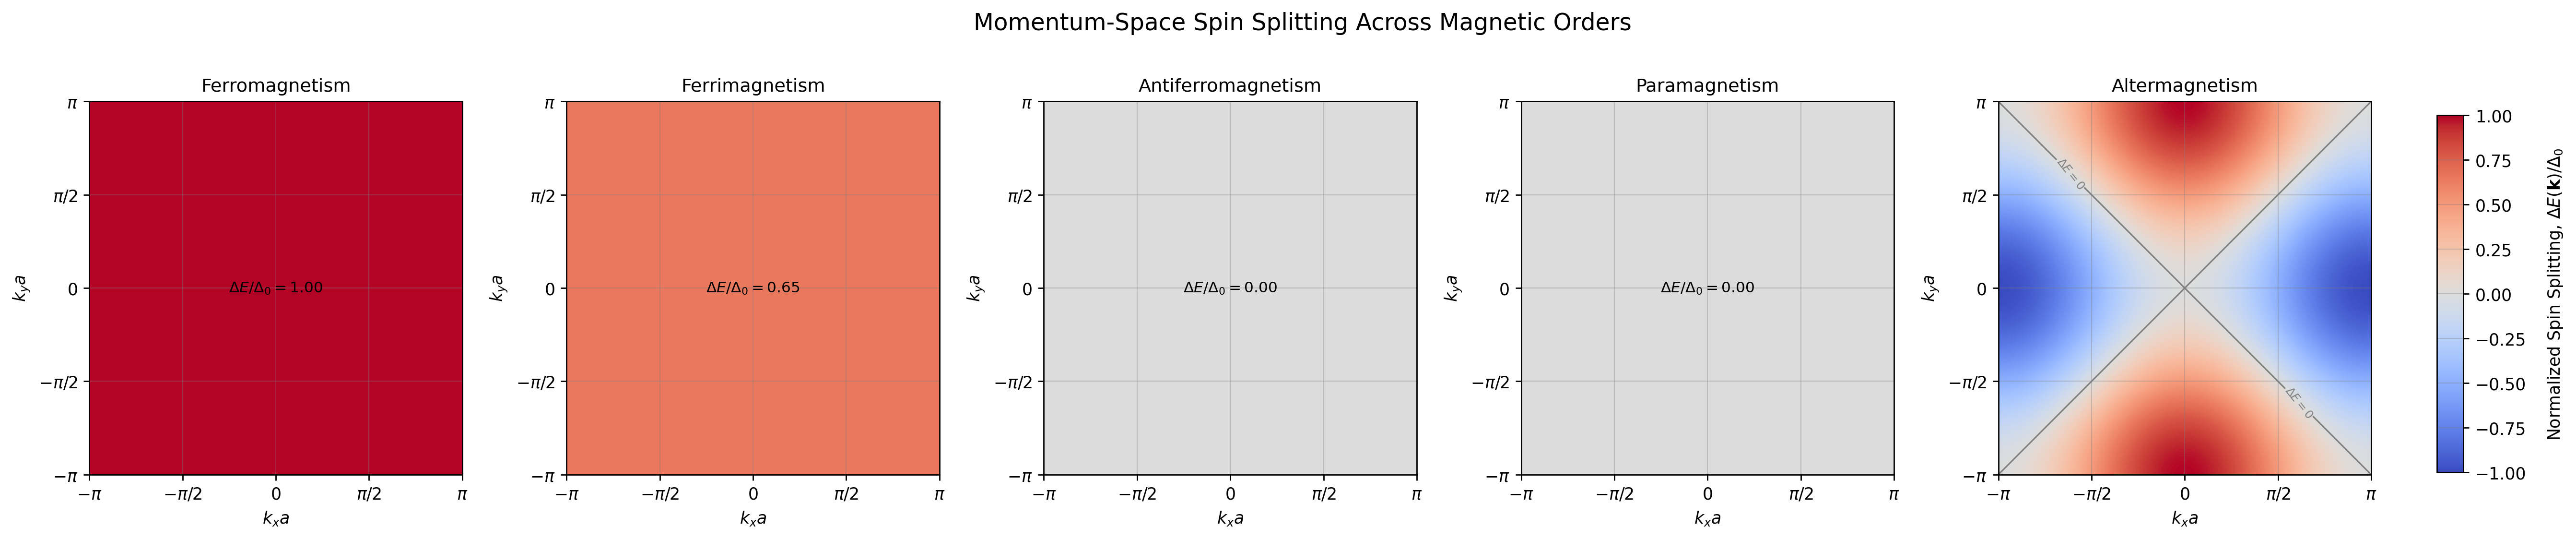

In [6]:
"""Plot side-by-side momentum-space spin-splitting maps."""

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.axes import Axes
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize


# ------------------------------------------------------------
# CONTROL KNOBS
# ------------------------------------------------------------

K_MIN = -np.pi
K_MAX = np.pi
K_POINTS = 301

LATTICE_CONSTANT = 1.0

# Normalized exchange or spin-splitting amplitudes.
FERRO_SPLITTING = 1.00
FERRI_SPLITTING = 0.65
ANTIFERRO_SPLITTING = 0.00
PARAMAGNET_SPLITTING = 0.00
ALTERMAGNET_SPLITTING_SCALE = 1.00

COLOR_LIMIT = 1.00
COLOR_MAP = "coolwarm"

# Figure configuration for five side-by-side heat maps.
FIGURE_WIDTH_INCHES = 22.0
FIGURE_HEIGHT_INCHES = 4.8
FIGURE_DPI = 250

GRID_COLOR = "gray"
GRID_ALPHA = 0.35
GRID_LINE_WIDTH = 0.6

TITLE_FONT_SIZE = 11
LABEL_FONT_SIZE = 10
ANNOTATION_FONT_SIZE = 9

# Main subplot margins.
SUBPLOT_LEFT = 0.040
SUBPLOT_RIGHT = 0.905
SUBPLOT_BOTTOM = 0.16
SUBPLOT_TOP = 0.84
SUBPLOT_WIDTH_SPACE = 0.28

# Dedicated color-bar position in normalized figure coordinates.
COLORBAR_LEFT = 0.930
COLORBAR_BOTTOM = 0.18
COLORBAR_WIDTH = 0.010
COLORBAR_HEIGHT = 0.62

COLORBAR_LABEL_PAD = 12


# ------------------------------------------------------------
# PLOTTING CONFIGURATION
# ------------------------------------------------------------


def configure_plotting() -> None:
    """Configure Matplotlib defaults for high-resolution Colab output."""
    plt.rcParams.update(
        {
            "figure.dpi": FIGURE_DPI,
            "savefig.dpi": FIGURE_DPI,
            "grid.color": GRID_COLOR,
            "grid.alpha": GRID_ALPHA,
            "grid.linewidth": GRID_LINE_WIDTH,
            "font.size": 10,
        }
    )


# ------------------------------------------------------------
# MOMENTUM-SPACE MODELS
# ------------------------------------------------------------


def calculate_uniform_spin_splitting(
    k_x: np.ndarray,
    magnitude: float,
) -> np.ndarray:
    """Calculate a momentum-independent spin-splitting field.

    This minimal Stoner-like representation emphasizes a common sign
    of exchange splitting across reciprocal space.

    Args:
        k_x: Reciprocal-space array defining the output shape.
        magnitude: Normalized spin-splitting magnitude.

    Returns:
        Momentum-independent spin-splitting array.
    """
    return np.full_like(
        k_x,
        magnitude,
        dtype=float,
    )


def calculate_altermagnetic_spin_splitting(
    k_x: np.ndarray,
    k_y: np.ndarray,
) -> np.ndarray:
    """Calculate a minimal d-wave-like altermagnetic spin splitting.

    The model is

        Delta(k) = Delta_0 / 2 * [cos(k_x a) - cos(k_y a)].

    Opposite signs occur along crystallographically related momentum
    directions, with nodal lines separating the spin-split sectors.

    Args:
        k_x: Reciprocal-space x coordinates.
        k_y: Reciprocal-space y coordinates.

    Returns:
        Normalized momentum-dependent altermagnetic spin splitting.
    """
    x_term = np.cos(k_x * LATTICE_CONSTANT)
    y_term = np.cos(k_y * LATTICE_CONSTANT)

    return (
        0.5
        * ALTERMAGNET_SPLITTING_SCALE
        * (x_term - y_term)
    )


def build_spin_splitting_maps(
    k_x: np.ndarray,
    k_y: np.ndarray,
) -> dict[str, np.ndarray]:
    """Build representative spin-splitting maps for five magnetic orders.

    Ferromagnetic and ferrimagnetic models use uniform exchange
    splitting. Conventional antiferromagnetic and paramagnetic
    baselines are spin degenerate in this simplified zero-field model.
    Altermagnetism uses alternating d-wave-like splitting.

    Args:
        k_x: Reciprocal-space x coordinates.
        k_y: Reciprocal-space y coordinates.

    Returns:
        Magnetic-order names mapped to normalized spin-splitting arrays.
    """
    return {
        "Ferromagnetism": calculate_uniform_spin_splitting(
            k_x,
            FERRO_SPLITTING,
        ),
        "Ferrimagnetism": calculate_uniform_spin_splitting(
            k_x,
            FERRI_SPLITTING,
        ),
        "Antiferromagnetism": calculate_uniform_spin_splitting(
            k_x,
            ANTIFERRO_SPLITTING,
        ),
        "Paramagnetism": calculate_uniform_spin_splitting(
            k_x,
            PARAMAGNET_SPLITTING,
        ),
        "Altermagnetism": calculate_altermagnetic_spin_splitting(
            k_x,
            k_y,
        ),
    }


# ------------------------------------------------------------
# INDIVIDUAL HEAT-MAP PANEL
# ------------------------------------------------------------


def plot_spin_splitting_panel(
    axis: Axes,
    magnetic_order: str,
    k_x: np.ndarray,
    k_y: np.ndarray,
    spin_splitting: np.ndarray,
) -> None:
    """Plot one momentum-space spin-splitting panel.

    Args:
        axis: Matplotlib axis receiving the heat map.
        magnetic_order: Display name of the magnetic order.
        k_x: Reciprocal-space x coordinates.
        k_y: Reciprocal-space y coordinates.
        spin_splitting: Normalized spin-splitting field.
    """
    axis.pcolormesh(
        k_x,
        k_y,
        spin_splitting,
        shading="auto",
        cmap=COLOR_MAP,
        vmin=-COLOR_LIMIT,
        vmax=COLOR_LIMIT,
    )

    # Momentum-dependent maps receive a zero-splitting nodal contour.
    if np.ptp(spin_splitting) > 1.0e-12:
        zero_contour = axis.contour(
            k_x,
            k_y,
            spin_splitting,
            levels=[0.0],
            colors=GRID_COLOR,
            linewidths=0.9,
        )

        axis.clabel(
            zero_contour,
            inline=True,
            fontsize=7,
            fmt={0.0: r"$\Delta E=0$"},
        )

    # Uniform maps receive their constant splitting as an annotation.
    else:
        normalized_value = float(spin_splitting.flat[0])

        axis.text(
            0.0,
            0.0,
            rf"$\Delta E/\Delta_0={normalized_value:.2f}$",
            horizontalalignment="center",
            verticalalignment="center",
            fontsize=ANNOTATION_FONT_SIZE,
        )

    axis.set_title(
        magnetic_order,
        fontsize=TITLE_FONT_SIZE,
    )
    axis.set_xlabel(
        r"$k_x a$",
        fontsize=LABEL_FONT_SIZE,
    )
    axis.set_ylabel(
        r"$k_y a$",
        fontsize=LABEL_FONT_SIZE,
    )

    axis.set_xlim(K_MIN, K_MAX)
    axis.set_ylim(K_MIN, K_MAX)

    axis.set_xticks(
        [-np.pi, -np.pi / 2.0, 0.0, np.pi / 2.0, np.pi],
        labels=[
            r"$-\pi$",
            r"$-\pi/2$",
            r"$0$",
            r"$\pi/2$",
            r"$\pi$",
        ],
    )

    axis.set_yticks(
        [-np.pi, -np.pi / 2.0, 0.0, np.pi / 2.0, np.pi],
        labels=[
            r"$-\pi$",
            r"$-\pi/2$",
            r"$0$",
            r"$\pi/2$",
            r"$\pi$",
        ],
    )

    axis.set_aspect("equal")

    axis.grid(
        visible=True,
        color=GRID_COLOR,
        alpha=GRID_ALPHA,
        linewidth=GRID_LINE_WIDTH,
    )


# ------------------------------------------------------------
# COLOR BAR
# ------------------------------------------------------------


def add_shared_color_bar(
    figure: plt.Figure,
) -> None:
    """Add a shared color bar outside the heat-map plotting area.

    Args:
        figure: Matplotlib figure receiving the dedicated color-bar axis.
    """
    normalization = Normalize(
        vmin=-COLOR_LIMIT,
        vmax=COLOR_LIMIT,
    )

    scalar_mappable = ScalarMappable(
        norm=normalization,
        cmap=COLOR_MAP,
    )
    scalar_mappable.set_array([])

    # Create an independent axis outside the five heat-map panels.
    color_bar_axis = figure.add_axes(
        [
            COLORBAR_LEFT,
            COLORBAR_BOTTOM,
            COLORBAR_WIDTH,
            COLORBAR_HEIGHT,
        ]
    )

    color_bar = figure.colorbar(
        scalar_mappable,
        cax=color_bar_axis,
        orientation="vertical",
    )

    color_bar.set_label(
        r"Normalized Spin Splitting, "
        r"$\Delta E(\mathbf{k})/\Delta_0$",
        labelpad=COLORBAR_LABEL_PAD,
    )


# ------------------------------------------------------------
# COMBINED FIGURE
# ------------------------------------------------------------


def plot_spin_splitting_comparison(
    k_x: np.ndarray,
    k_y: np.ndarray,
    spin_splitting_maps: dict[str, np.ndarray],
) -> None:
    """Plot all magnetic-order heat maps horizontally in one figure.

    Args:
        k_x: Reciprocal-space x coordinates.
        k_y: Reciprocal-space y coordinates.
        spin_splitting_maps: Magnetic-order names mapped to splitting arrays.
    """
    figure, axes = plt.subplots(
        nrows=1,
        ncols=len(spin_splitting_maps),
        figsize=(
            FIGURE_WIDTH_INCHES,
            FIGURE_HEIGHT_INCHES,
        ),
        sharex=True,
        sharey=True,
    )

    for axis, (magnetic_order, spin_splitting) in zip(
        axes,
        spin_splitting_maps.items(),
        strict=True,
    ):
        plot_spin_splitting_panel(
            axis=axis,
            magnetic_order=magnetic_order,
            k_x=k_x,
            k_y=k_y,
            spin_splitting=spin_splitting,
        )

    # Restore y-axis tick labels for every shared-axis panel.
    for axis in axes:
        axis.tick_params(
            axis="y",
            labelleft=True,
        )

    figure.suptitle(
        "Momentum-Space Spin Splitting Across Magnetic Orders",
        fontsize=14,
        y=0.98,
    )

    # Reserve the region to the right for the independent color bar.
    figure.subplots_adjust(
        left=SUBPLOT_LEFT,
        right=SUBPLOT_RIGHT,
        bottom=SUBPLOT_BOTTOM,
        top=SUBPLOT_TOP,
        wspace=SUBPLOT_WIDTH_SPACE,
    )

    add_shared_color_bar(figure)

    plt.show()


# ------------------------------------------------------------
# MAIN PROGRAM
# ------------------------------------------------------------


def main() -> None:
    """Generate the side-by-side reciprocal-space comparison."""
    configure_plotting()

    k_values = np.linspace(
        K_MIN,
        K_MAX,
        K_POINTS,
    )

    k_x, k_y = np.meshgrid(
        k_values,
        k_values,
        indexing="xy",
    )

    spin_splitting_maps = build_spin_splitting_maps(
        k_x,
        k_y,
    )

    plot_spin_splitting_comparison(
        k_x=k_x,
        k_y=k_y,
        spin_splitting_maps=spin_splitting_maps,
    )


if __name__ == "__main__":
    main()